<a href="https://colab.research.google.com/github/mochamadx5/PCVK26_11_MochamadReza/blob/main/P3_Praktikum_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import hashlib
import datetime
import zoneinfo
import platform
import sys

NAMA = 'Mochamad Reza Firdaus'
NIM = '244107020104'  # ganti dengan NIM Anda

N = int(NIM[-3:])
PARAM = {
    'b': (N % 61) + 20,
    'a': round(1.0 + (N % 9) / 10, 1),
    'c': (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit': (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA  : ', NAMA)
print('NIM   : ', NIM, ' | N = ', N)
for k, v in PARAM.items():
  print('%-6s: %s' % (k, v))
print('WAKTU : ', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA  :  Mochamad Reza Firdaus
NIM   :  244107020104  | N =  104
b     : 63
a     : 1.5
c     : 34
gamma : 0.9
bit   : 4
WAKTU :  2026-09-23 21:06:31 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : c0e8c7d08b3b7a7a


In [26]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Menggunakan nilai parameter brightness (b) = 63


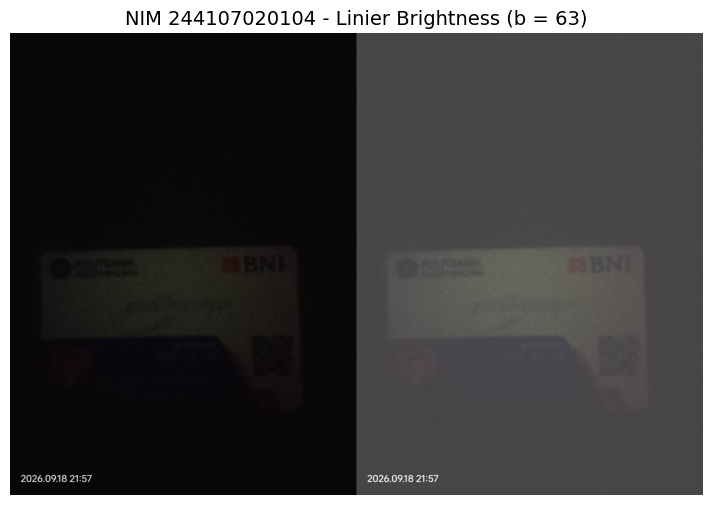

In [28]:
# Path folder Google Drive
BASE_PATH = '/content/drive/MyDrive/PCVK/'

# Mengambil nilai b dari dictionary PARAM yang sudah dibuat di sel identitas
brightness = PARAM['b']
print(f'Menggunakan nilai parameter brightness (b) = {brightness}')

# Membaca citra KTM1a.jpg (atau bisa diganti dengan KTM1b.jpg)
original = cv2.imread(BASE_PATH + 'KTM1a.jpg')

if original is None:
  print(
      'Citra tidak ditemukan! Pastikan path dan nama file di Google Drive'
      ' sudah benar.'
  )
else:
  # Konversi BGR ke RGB untuk ditampilkan via Matplotlib
  original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

  # Menerapkan Linier Brightness dengan np.clip (fungsi Truncate agar batas aman 0-255)
  brightness_image = np.clip(
      original_rgb.astype(np.int16) + brightness, 0, 255
  ).astype(np.uint8)

  # Menggabungkan gambar asli dan hasil secara berdampingan (horizontal)
  final_frame = np.hstack((original_rgb, brightness_image))

  # Menampilkan hasil dengan judul yang memuat NIM
  plt.figure(figsize=(12, 6))
  plt.imshow(final_frame)
  plt.title(
      f'NIM 244107020104 - Linier Brightness (b = {brightness})', fontsize=14
  )
  plt.axis('off')
  plt.show()

In [29]:
# 1. Baca citra KTM1a (ruangan gelap) dan KTM1b (lampu ruangan)
img_a = cv2.imread(BASE_PATH + 'KTM1a.jpg')
img_b = cv2.imread(BASE_PATH + 'KTM1b.jpg')

# Konversi BGR ke RGB untuk visualisasi Matplotlib
img_a_rgb = cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB)
img_b_rgb = cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB)

# 2. Proses Inverse Citra (Citra Negatif)
inv_a = 255 - img_a_rgb
inv_b = 255 - img_b_rgb

# 3. Tampilkan citra asli dan hasil inverse berdampingan
plt.figure(figsize=(12, 10))


<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

(np.float64(-0.5), np.float64(2447.5), np.float64(3263.5), np.float64(-0.5))

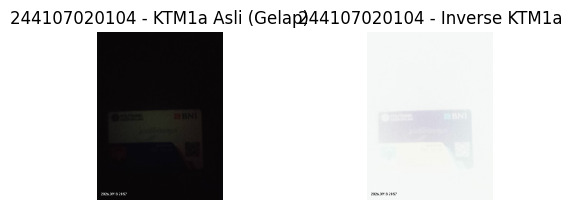

In [30]:
# KTM1a Asli vs Inverse
plt.subplot(2, 2, 1)
plt.imshow(img_a_rgb)
plt.title('244107020104 - KTM1a Asli (Gelap)')
plt.axis('off')
plt.subplot(2, 2, 2)

plt.imshow(inv_a)
plt.title('244107020104 - Inverse KTM1a')
plt.axis('off')

(np.float64(-0.5), np.float64(1835.5), np.float64(1835.5), np.float64(-0.5))

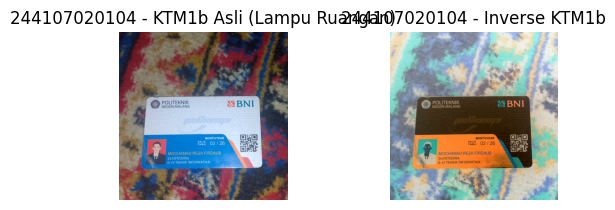

In [31]:
# KTM1b Asli vs Inverse
plt.subplot(2, 2, 3)
plt.imshow(img_b_rgb)
plt.title('244107020104 - KTM1b Asli (Lampu Ruangan)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(inv_b)
plt.title('244107020104 - Inverse KTM1b')
plt.axis('off')

In [32]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

Menerapkan Transformasi Kontras:
- Nilai Kontras (a) = 1.5
- Nilai Brightness (b) = 63


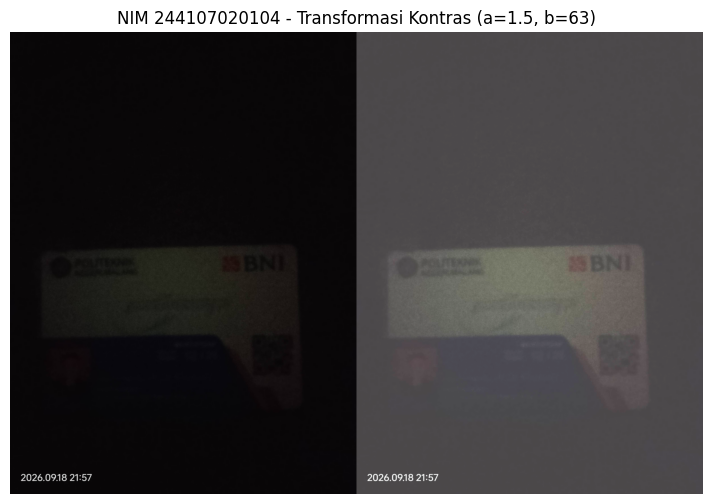

In [33]:
# 2. Mengambil nilai a (kontras) dan b (brightness) dari dictionary PARAM
val_a = PARAM['a']
val_b = PARAM['b']

print(f'Menerapkan Transformasi Kontras:')
print(f'- Nilai Kontras (a) = {val_a}')
print(f'- Nilai Brightness (b) = {val_b}')

# Membaca citra KTM1a.jpg
original = cv2.imread(BASE_PATH + 'KTM1a.jpg')

if original is None:
  print(
      'Citra KTM1a.jpg tidak ditemukan! Periksa kembali nama file dan foldernya.'
  )
else:
  # Konversi BGR ke RGB untuk visualisasi Matplotlib
  original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

  # Melakukan operasi transformasi kontras dan brightness dengan np.clip (Truncate 0-255)
  # Menggunakan float32 agar perkalian desimal (1.5) akurat sebelum diubah ke uint8
  contrast_image = np.clip(
      original_rgb.astype(np.float32) * val_a + val_b, 0, 255
  ).astype(np.uint8)

  # Menggabungkan citra asli dan hasil transformasi secara berdampingan
  final_frame = np.hstack((original_rgb, contrast_image))

  # Menampilkan hasil dengan judul memuat NIM
  plt.figure(figsize=(12, 6))
  plt.imshow(final_frame)
  plt.title(
      f'NIM 244107020104 - Transformasi Kontras (a={val_a}, b={val_b})',
      fontsize=12,
  )
  plt.axis('off')
  plt.show()

Parameter Logarithmic Brightness (c) = 34
Parameter Linier Brightness (b) = 63


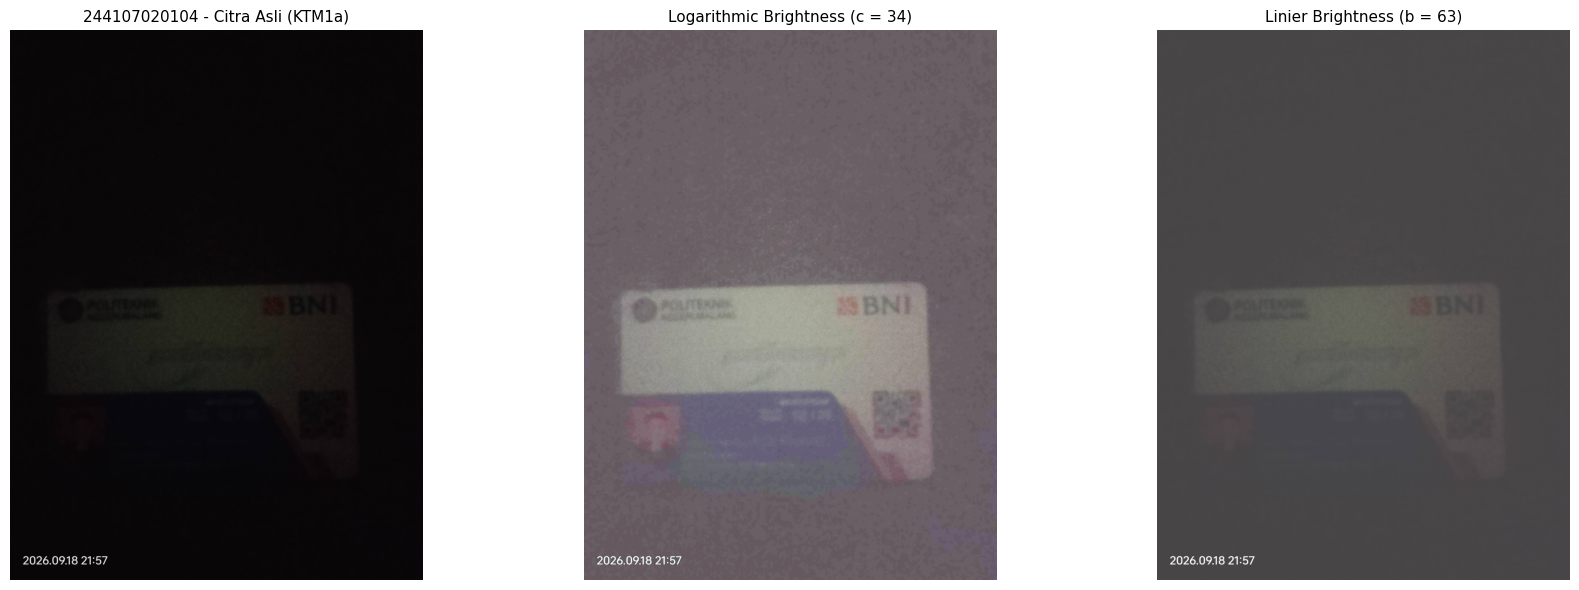

In [34]:
# 3. Logaritmic Brightness
# Ambil parameter dari dictionary PARAM
c_val = PARAM['c']  # 34
b_val = PARAM['b']  # 63

print(f'Parameter Logarithmic Brightness (c) = {c_val}')
print(f'Parameter Linier Brightness (b) = {b_val}')

# Membaca citra KTM1a.jpg
original = cv2.imread(BASE_PATH + 'KTM1a.jpg')

if original is None:
  print('Citra KTM1a.jpg tidak ditemukan! Periksa kembali path folder Anda.')
else:
  # Konversi BGR ke RGB untuk visualisasi Matplotlib
  original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

  # 1. Transformasi Logarithmic Brightness
  img_float = original_rgb.astype(np.float32)
  # Formula: s = c * log(1 + r)
  log_image_raw = c_val * np.log(1 + img_float)
  # Normalisasi hasil log agar pas merata pada rentang 0-255
  log_image = cv2.normalize(
      log_image_raw, None, 0, 255, cv2.NORM_MINMAX
  ).astype(np.uint8)

  # 2. Transformasi Linier Brightness (untuk perbandingan)
  # Formula: g(x,y) = f(x,y) + b (menggunakan np.clip untuk truncate 0-255)
  linear_image = np.clip(
      original_rgb.astype(np.int16) + b_val, 0, 255
  ).astype(np.uint8)

  # Menampilkan perbandingan dalam satu baris (Asli vs Logarithmic vs Linier)
  plt.figure(figsize=(18, 6))

  plt.subplot(1, 3, 1)
  plt.imshow(original_rgb)
  plt.title('244107020104 - Citra Asli (KTM1a)', fontsize=11)
  plt.axis('off')

  plt.subplot(1, 3, 2)
  plt.imshow(log_image)
  plt.title(f'Logarithmic Brightness (c = {c_val})', fontsize=11)
  plt.axis('off')

  plt.subplot(1, 3, 3)
  plt.imshow(linear_image)
  plt.title(f'Linier Brightness (b = {b_val})', fontsize=11)
  plt.axis('off')

  plt.tight_layout()
  plt.show()

1. Metode mana yang membuat NIM pada kartu Anda lebih terbaca?
- Jawaban: Logarithmic Brightness jauh lebih efektif membuat teks dan NIM pada gambar lebih terbaca.
- Alasan: Citra KTM1a diambil di dalam ruangan gelap sehingga memiliki rentang intensitas piksel yang sangat sempit di area bawah (gelap). Transformasi logaritma bekerja dengan cara memetakan range nilai gray-level rendah yang sempit menjadi lebih lebar pada citra output. Hal ini menaikkan detail-detail tersembunyi di area gelap tanpa merusak area terang.   
2. Tunjukkan bagian mana yang menjadi putih penuh (clipping) pada masing-masing metode:
- Linier Brightness: Mengalami clipping di bagian latar belakang yang relatif terang atau pada area yang terkena pantulan cahaya/lensa secara langsung. Ini terjadi karena operasi penambahan konstan (b = 63) menggeser seluruh nilai piksel secara rata, sehingga piksel yang awalnya sudah agak tinggi langsung menembus batas maksimum 255 dan terpangkas (truncated) menjadi putih mutlak
- Logarithmic Brightness: Minim atau bahkan tidak mengalami clipping ekstrem di area terang. Karakteristik kurva logaritma yang melandai mencegah piksel terang mengalami kejenuhan berlebih, sehingga transisi warna tetap terjaga dan detail objek di sekitar area terang tetap terlihat.

==- Tabel Statistik Intensitas Citra Grayscale ===
    Metode Grayscale   Mean  Std Dev
           Averaging 107.26    60.37
           Lightness 107.83    60.31
Luminance (Rec. 709) 104.19    60.92




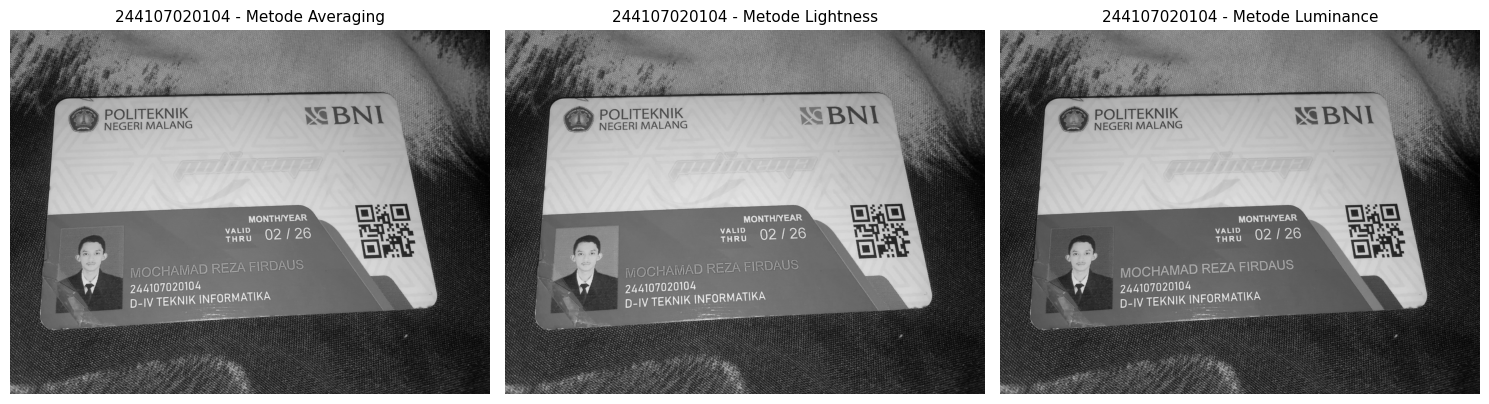

In [35]:
# 3. Transformasi Grayscale (Averaging, Lightness, dan Luminance)
import pandas as pd
# Membaca citra KTM1c.jpg (foto dengan flash)
original = cv2.imread(BASE_PATH + 'KTM1c.jpg')
if original is None:
  print('Citra KTM1c.jpg tidak ditemukan! Periksa kembali path folder Anda.')
else:
  # Konversi BGR ke RGB agar urutan channel benar (R=0, G=1, B=2)
  img_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
  R = img_rgb[:, :, 0].astype(np.float32)
  G = img_rgb[:, :, 1].astype(np.float32)
  B = img_rgb[:, :, 2].astype(np.float32)

  #1. Metode Averaging (R + G +B) / 3
  gray_avg = np.round((R + G + B) / 3).astype(np.uint8)

  #2. Metode Lightness : (max(R, G, B) + min(R, G, B)) /2
  max_val = np.maximum(np.maximum(R, G), B)
  min_val = np.minimum(np.minimum(R, G), B)
  gray_light = np.round((max_val + min_val) / 2).astype(np.uint8)

  #3. Metode Luminance 0.21R + 0.72G + 0.07B
  gray_luminance = np.round(0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

  #Menghitung mean dan simpangan baku
  stats_data = {
      'Metode Grayscale': ['Averaging', 'Lightness', 'Luminance (Rec. 709)'],
      'Mean': [
          round(np.mean(gray_avg), 2),
          round(np.mean(gray_light), 2),
          round(np.mean(gray_luminance), 2),
      ],
      'Std Dev': [
          round(np.std(gray_avg), 2),
          round(np.std(gray_light), 2),
          round(np.std(gray_luminance), 2),
      ],
  }
  df_stats = pd.DataFrame(stats_data)
  print('==- Tabel Statistik Intensitas Citra Grayscale ===')
  print(df_stats.to_string(index=False))
  print('\n')

  # Visualisasi hasil ketiga metode grayscale secara berdampingan
  plt.figure(figsize=(15, 5))

  plt.subplot(1, 3, 1)
  plt.imshow(gray_avg, cmap='gray')
  plt.title('244107020104 - Metode Averaging', fontsize=11)
  plt.axis('off')

  plt.subplot(1, 3, 2)
  plt.imshow(gray_light, cmap='gray')
  plt.title('244107020104 - Metode Lightness', fontsize=11)
  plt.axis('off')

  plt.subplot(1, 3, 3)
  plt.imshow(gray_luminance, cmap='gray')
  plt.title('244107020104 - Metode Luminance', fontsize=11)
  plt.axis('off')

  plt.tight_layout()
  plt.show()

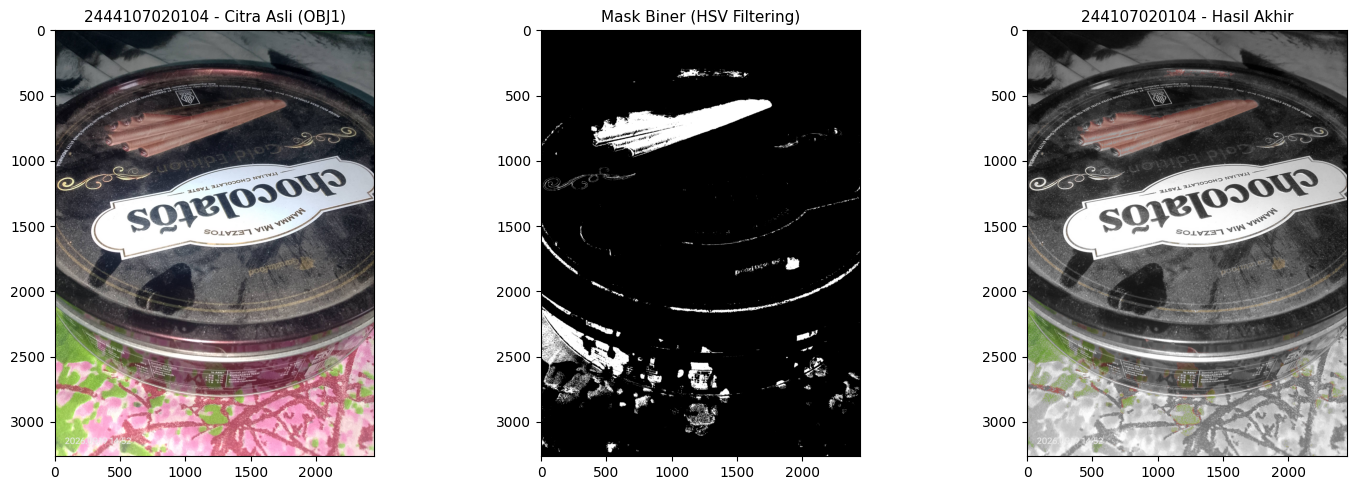

In [36]:
# 5. Image Masking / Color Filtering (Menampilkan Satu Warna Tertentu dan Mengubah Lainnya Menjadi Grayscale)

# Membaca citra OBJ1.jpg (benda dengan satu warna dominan)
original = cv2.imread(BASE_PATH + 'OBJ1.jpg')

if original is None:
  print('Citra OBJ1.jpg tidak ditemukan! Periksa kembali path folder Anda.')
else:
  # 1. Konversi dari BGR ke RGB untuk visualisasi, dan ke HSV untuk filtering warna
  original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
  hsv = cv2.cvtColor(original, cv2.COLOR_BGR2HSV)

  # 2. Tentukan rentang batas bawah (lower) dan batas atas (upper) HSV
  # CONTOH di bawah ini menggunakan rentang warna MERAH.
  # Silakan ubah nilai ini sesuai dengan warna dominan objek Anda (misal: biru, hijau, kuning, dll).
  lower_bound = np.array([0, 50, 80])
  upper_bound = np.array([50, 255, 180])

  #3. membuat mask biner menggunakan cv2.iRange
  mask = cv2.inRange(hsv, lower_bound, upper_bound)

  #4. Mengubah citra asli menjadi grayscale, lalu ubah ke 3 channel (RGB)
  gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
  gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

  #5. menerapkan masking : ambil warna asli di area mask, dan graysacale di luar
  mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
  result_image = np.where(mask_3ch == 255, original_rgb, gray_3ch)

  # 6. Menampilkan Hasil (Citra Asli, Mask, dan hasil akhir)
  plt.figure(figsize=(15, 5))

  plt.subplot(1, 3, 1)
  plt.imshow(original_rgb)
  plt.title('2444107020104 - Citra Asli (OBJ1)', fontsize=11)
  plt.axis('On')

  plt.subplot(1, 3, 2)
  plt.imshow(mask, cmap='gray')
  plt.title('Mask Biner (HSV Filtering)', fontsize=11)
  plt.axis('On')

  plt.subplot(1, 3, 3)
  plt.imshow(result_image)
  plt.title('244107020104 - Hasil Akhir', fontsize=11)
  plt.axis('On')

  plt.tight_layout()
  plt.show()

1. Rentang Nilai HSV yang Digunakan:
- Lower: [0, 50, 80], Upper: [50, 255, 180]

2. Pengaruh Apabila Rentang Diperlebar :

- Jika rentang HSV diperlebar, mask akan menangkap lebih banyak gradasi warna yang mirip dengan target. Akibatnya, bagian latar belakang atau objek lain yang memiliki kemiripan warna dengan objek utama akan ikut lolos dari efek grayscale.

3. Pengaruh Apabila Rentang Dipersempit :
- Jika rentang HSV dipersempit, seleksi warna akan menjadi sangat selektif dan ketat. Risikonya, bagian dari objek utama sendiri yang memiliki bayangan atau perbedaan intensitas cahaya yang tidak merata tidak akan tertangkap oleh mask, sehingga objek tersebut akan tampak terpotong-potong atau sebagian berubah menjadi abu-abu (grayscale).

Nilai Gamma: 0.9


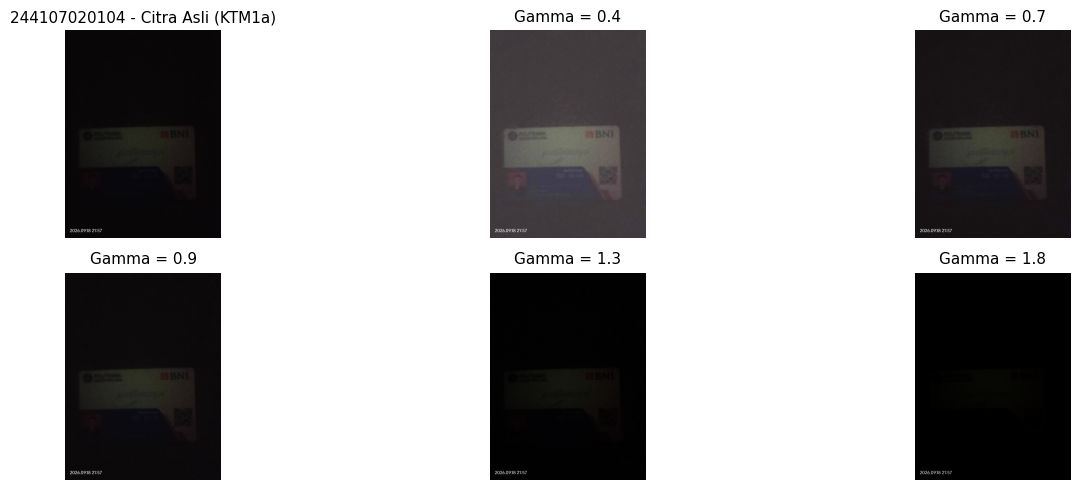

In [37]:
# 6. Gamma correction
# nilai gamma awal berdasarkan perhitungan NIM
gamma_nim = PARAM['gamma']
print(f'Nilai Gamma: {gamma_nim}')

# membaca citra KTM1a (ruang gelap)
original = cv2.imread(BASE_PATH + 'KTM1a.jpg')

#konversi bgr ke rgb untuk visualisasi matplotlin
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# menentukan 5 nilai gamma
gamma_list = [0.4, 0.7, gamma_nim, 1.3, 1.8]

plt.figure(figsize=(15, 5))

#plot citra asli
plt.subplot(2, 3, 1)
plt.imshow(original_rgb)
plt.title('244107020104 - Citra Asli (KTM1a)', fontsize=11)
plt.axis('off')

#Melakukan iterasi untuk setiap nilai gamma
for i, g in enumerate(gamma_list) :
  #formula gamma correction ; I' = 255 * (I / 255) ^ gamma
  normalized = original_rgb.astype(np.float32) / 255.0
  corrected = np.power(normalized, g) * 255.0
  gamma_image = np.clip(corrected, 0, 255).astype(np.uint8)

  #koreksi hasil gamma
  plt.subplot(2, 3, i+2)
  plt.imshow(gamma_image)
  plt.title(f'Gamma = {g}', fontsize=11)
  plt.axis('off')

plt.tight_layout()
plt.show()

1. Nilai Gamma Terbaik:
- 0.4
2. Penjelasan Mengapa Nilai Terbaik Setiap Mahasiswa Berbeda:
- Meskipun jenis objeknya sama yaitu KTM, kondisi pencahayaan saat akuisisi di ruangan gelap milik setiap mahasiswa pasti berbeda-beda. Ada mahasiswa yang mengambil foto di ruangan yang benar-benar gulita total, sementara yang lain mungkin masih mendapati sedikit pantulan cahaya tipis dari celah pintu atau lampu indikator perangkat. Oleh karena itu, intensitas piksel dasar pada citra setiap orang berbeda, sehingga faktor koreksi gamma yang optimal untuk menaikkan detail bayangan tanpa membuat citra terlalu silau akan bervariasi bagi setiap individu.   

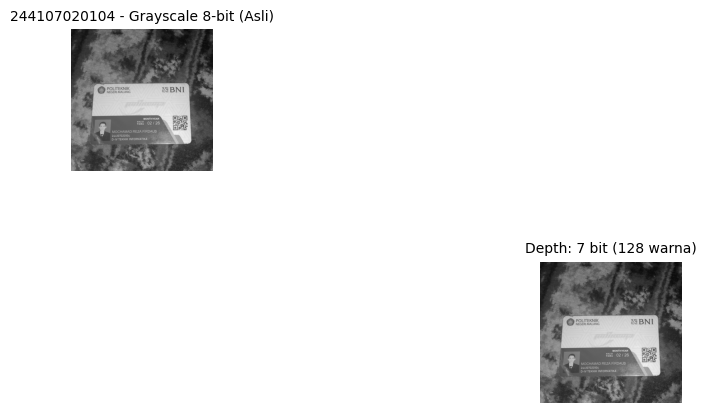

In [38]:
# Simulasi Image Depth pada Citra Pribadi
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Membaca citra KTM1b.jpg dalam mode Grayscale
original = cv2.imread(BASE_PATH + 'KTM1b.jpg', cv2.IMREAD_GRAYSCALE)

# 1. Menampilkan citra Grayscale standar (8-bit) sebagai pembanding awal
plt.subplot(2, 4, 1)
plt.imshow(original, cmap='gray', vmin=0, vmax=255)
plt.title('244107020104 - Grayscale 8-bit (Asli)', fontsize=10)
plt.axis('off')

# 2. Loop untuk simulasi Image Depth dari 1 bit sampai 7 bit
for i, bit_depth in enumerate(range(1, 8)):
  # Menghitung jarak antar level berdasarkan rumus pada modul
  level = 255 / (pow(2, bit_depth) - 1)

# Proses kuantisasi / simulasi kedalaman bit
depth_image = np.round(original / level) * level
depth_image = depth_image.astype(np.uint8)

# Menampilkan hasil per bit depth
plt.subplot(2, 4, i + 2)
plt.imshow(depth_image, cmap='gray', vmin=0, vmax=255)
num_colors = 2**bit_depth
plt.title(f'Depth: {bit_depth} bit ({num_colors} warna)', fontsize=10)
plt.axis('off')

plt.tight_layout()
plt.show()

Berhasil! File zip noises telah diekstrak.
Jumlah citra noise yang berhasil ditemukan di folder: 100


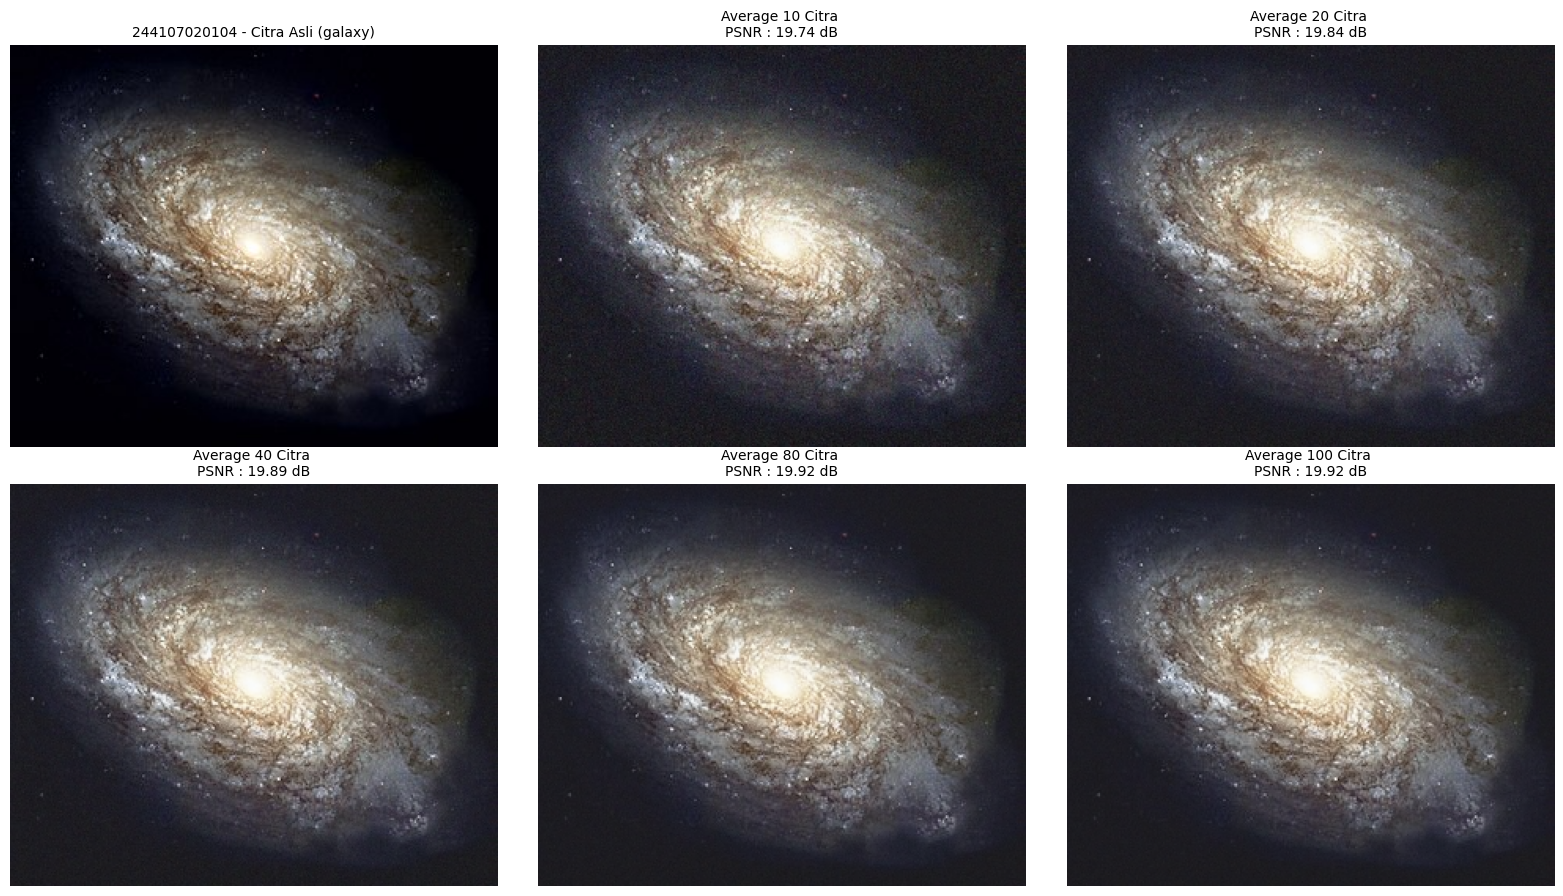

=== Tabel Rekapitulasi PSNR ===
 Count  PSNR
    10 19.74
    20 19.84
    40 19.89
    80 19.92
   100 19.92




In [39]:
import glob
import os
import zipfile
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Tentukan path utama tempat folder noises dan galaxy.jpg berada
BASE_DIR = '/content/drive/MyDrive/PCVK/'
ZIP_PATH = BASE_DIR + 'noises-image.zip'
EXTRACT_PATH = BASE_DIR

# Proses ekstraksi otomatis jika file zip ada
if os.path.exists(ZIP_PATH):
  with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
  print('Berhasil! File zip noises telah diekstrak.')
else:
  print('File zip tidak ditemukan, periksa kembali path lokasinya.')


# 1. Fungsi PSNR yang sudah dikoreksi sesuai catatan modul
def calculate_psnr(img1, img2):
  img1 = img1.astype(np.float64)
  img2 = img2.astype(np.float64)
  mse = np.mean((img1 - img2) ** 2)
  if mse == 0:
    return float('inf')
  return 20 * np.log10(255.0 / np.sqrt(mse))


# 2. Membaca citra asli (galaxy.jpg)
# Coba muat dari folder utama PCVK, atau sesuaikan jika di dalam folder NIM
original_galaxy = cv2.imread(BASE_DIR + 'galaxy.jpg')
if original_galaxy is None:
  # Alternatif path jika tersimpan di dalam folder NIM Anda
  original_galaxy = cv2.imread(BASE_DIR + 'galaxy.jpg')

if original_galaxy is not None:
  original_rgb = cv2.cvtColor(original_galaxy, cv2.COLOR_BGR2RGB)

  # 3. Membaca seluruh file citra noise menggunakan glob
  noise_paths = glob.glob(BASE_DIR + 'noises/*.jpg')
  noise_paths.sort()  # Urutkan agar konsisten

  print(
      f'Jumlah citra noise yang berhasil ditemukan di folder:'
      f' {len(noise_paths)}'
  )

  cv_img = []
  if len(noise_paths) > 0:
    for img_path in noise_paths:
      n = cv2.imread(img_path)
      if n is not None:
        cv_img.append(n)

    # 4. Melakukan Average Denoising untuk jumlah citra
    sample_counts = [10, 20, 40, 80, 100]
    results = []

    plt.figure(figsize=(16, 9))

    # Tampilkan citra asli di urutan pertama
    plt.subplot(2, 3, 1)
    plt.imshow(original_rgb)
    plt.title('244107020104 - Citra Asli (galaxy)', fontsize=10)
    plt.axis('off')

    for idx, count in enumerate(sample_counts):
      if count <= len(cv_img):
        # Ambil subset citra sebanyak 'count'
        subset = cv_img[:count]

        # Hitung rata-rata piksel dari subset citra
        avg_img = np.mean(subset, axis=0).astype(np.float64)
        avg_img_uint8 = np.clip(avg_img, 0, 255).astype(np.uint8)

        # Konversi ke RGB untuk visualisasi Matplotlib
        avg_rgb = cv2.cvtColor(avg_img_uint8, cv2.COLOR_BGR2RGB)

        # Hitung nilai PSNRfmencari
        psnr_val = calculate_psnr(original_galaxy, avg_img_uint8)

        # Simpan hasil ke dalam list
        results.append({'Count': count, 'PSNR': round(psnr_val, 2)})

        # Plot hasil denoising
        plt.subplot(2, 3, idx + 2)
        plt.imshow(avg_rgb)
        plt.title(
            f'Average {count} Citra \nPSNR : {round(psnr_val, 2)} dB',
            fontsize=10,
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # 5. Cetak tabel rekapitulasi PSNR
    df_results = pd.DataFrame(results)
    print('=== Tabel Rekapitulasi PSNR ===')
    print(df_results.to_string(index=False))
    print('\n')
  else:
    print(
        'Folder noises/*.jpg kosong atau path salah! Periksa kembali direktori'
        ' Anda.'
    )
else:
  print('Citra galaxy.jpg tidak ditemukan di direktori utama!')

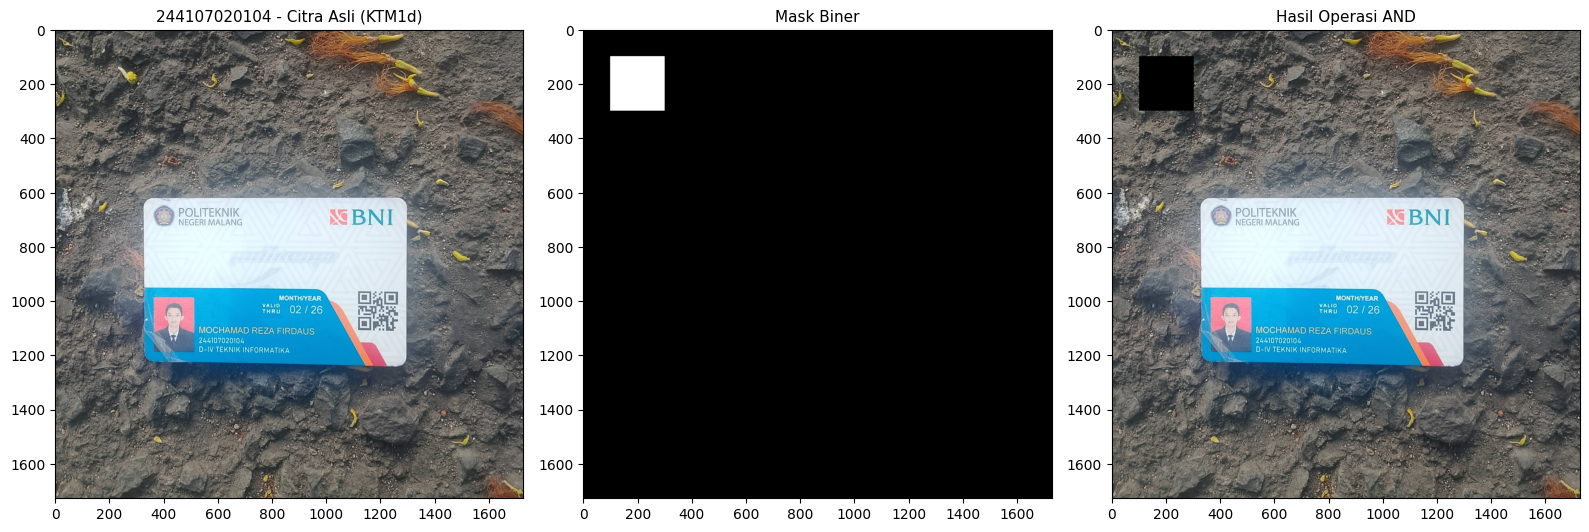

koordinat kotak mask yang digunakan
area wajah : x(60-180), y(180-340)
area NIM : x(180-380), y(280-360)


In [40]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# membaca KTM1d.jpg
original = cv2.imread(BASE_PATH + 'KTM1d.jpg')

if original is None:
  print('Citra KTM1d.jpg tidak ditemukan! Periksa kembali path folder Anda.')
else :
  # konversi BGR ke RGB
  original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
  h, w, _ = original_rgb.shape # Memperbaiki original_ ke original_rgb

  # 1. Membuat mask biner
  mask = np.zeros((h, w), dtype=np.uint8)

  cv2.rectangle(mask, (100, 100), (300, 300), 255, -1) # Melengkapi cv2.rectangle dengan warna 255 (putih) dan ketebalan -1 (terisi)

  inverse_mask = cv2.bitwise_not(mask)
  #operasi AND antara citra asli dengan inverse mask
  inverse_mask_3ch = cv2.cvtColor(inverse_mask, cv2.COLOR_GRAY2RGB)

  #operasi and antara cintra asli dengan inverse mask
  result_masked = cv2.bitwise_and(original_rgb, inverse_mask_3ch)

  # Menampilkan hasil
  plt.figure(figsize=(16, 6))

  plt.subplot(1,  3, 1)
  plt.imshow(original_rgb)
  plt.title('244107020104 - Citra Asli (KTM1d)', fontsize=11)
  plt.axis('on')

  plt.subplot(1, 3, 2)
  plt.imshow(mask, cmap='gray')
  plt.title('Mask Biner', fontsize=11)
  plt.axis('on')

  plt.subplot(1, 3, 3)
  plt.imshow(result_masked)
  plt.title('Hasil Operasi AND', fontsize=11)
  plt.axis('on')

  plt.tight_layout()
  plt.show()

  print('koordinat kotak mask yang digunakan')
  print('area wajah : x(60-180), y(180-340)')
  print('area NIM : x(180-380), y(280-360)')

1. NOT (Komplemen):
Kode: cv2.bitwise_not(original_rgb) atau cv2.bitwise_not(mask_3ch)   
- Analisis : Membalik seluruh nilai piksel citra yaitu menghasilkan efek warna negatif seperti foto negatif film. Area terang menjadi gelap dan sebaliknya.
2. OR (Atau):
Kode: cv2.bitwise_or(original_rgb, mask_3ch)   
- Analisis : Menggabungkan citra dengan mask. Karena area mask bernilai 255 pada bagian wajah dan NIM, pengoperasian OR membuat area wajah dan NIM berubah menjadi putih penuh (clipping).   
3. AND (Dan):
Kode: cv2.bitwise_and(original_rgb, inverse_mask_3ch)
- Analisis : Berfungsi sempurna sebagai penyamar data privat karena area yang ditunjuk oleh mask ditiadakan atau menjadi hitam, sementara bagian kartu lainnya tetap utuh.   
4. NAND (Not And):
Kode: cv2.bitwise_not(cv2.bitwise_and(original_rgb, mask_3ch))
Analisis : Kebalikan dari operasi AND. Area yang ditutup mask akan bernilai terbalik/negatif, sedangkan area luar mask ikut terpengaruh oleh inversi logika.   
5. XOR (Exclusive Or):
Kode: cv2.bitwise_xor(original_rgb, mask_3ch)
- Analisis : Menghasilkan pola bitwise eksklusif di mana area mask memicu pembalikan warna atau inverting secara selektif pada channel warna piksel yang dikenainya tanpa membuat area lain menjadi hitam pekat secara mutlak.   

10. Untuk file NIGH11.png, metode yang direkomendasikan adalah Logarithmic Brightness.
- Alasan : Foto konser memiliki rentang intensitas cahaya yang terlalu lebar. Maksudnya, antara area gelap panggung dan sorot lampu putih yang menyilaukan. Transformasi logaritma efektif untuk merentangkan nilai keabuan yang rendah menampilkan detail pakaian, alat musik, atau kertas NIM di area gelap sekaligus menekan pencahayaan berlebih pada area yang terlalu terang.
- risiko metode : Jika konstanta c diatur terlalu tinggi, gambar bisa mendadak terlalu kontras dan memunculkan noise digital yaitu bintik-bintik butiran piksel di area bayangan yang gelap.


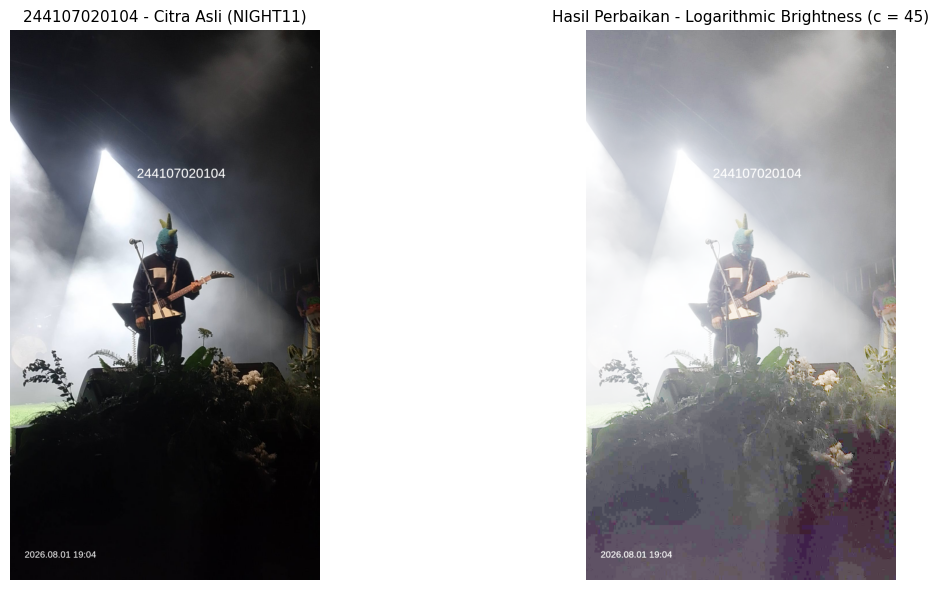

In [43]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Path direktori Google Drive Anda
BASE_PATH = '/content/drive/MyDrive/PCVK/'

# Membaca citra NIGHT11.png
original = cv2.imread(BASE_PATH + 'NIGHT11.png')

if original is None:
  print('Citra NIGHT11.png tidak ditemukan! Periksa kembali path folder Anda.')
else:
  # Konversi BGR ke RGB untuk visualisasi Matplotlib
  original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

  # Menggunakan Transformasi Logarithmic Brightness: s = c * log(1 + r)
  # Sangat bagus untuk foto malam dengan lampu sorot terang agar detail bayangan muncul
  c_val = 45  # Konstanta log (bisa disesuaikan antara 30 - 60)
  img_float = original_rgb.astype(np.float32)
  log_image_raw = c_val * np.log(1 + img_float)

  # Normalisasi hasil log agar kembali ke rentang 0-255 secara optimal
  log_image = cv2.normalize(
      log_image_raw, None, 0, 255, cv2.NORM_MINMAX
  ).astype(np.uint8)

  # Menampilkan perbandingan Before - After
  plt.figure(figsize=(14, 6))

  plt.subplot(1, 2, 1)
  plt.imshow(original_rgb)
  plt.title('244107020104 - Citra Asli (NIGHT11)', fontsize=11)
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(log_image)
  plt.title(f'Hasil Perbaikan - Logarithmic Brightness (c = {c_val})', fontsize=11)
  plt.axis('off')

  plt.tight_layout()
  plt.show()